In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#### experiments with derivatives
Derivative defines, how a function changes if we add a small change to the input point(x in this case), whether the value of the function goes up or down and by how much it changes.

In [3]:
# random function
def f(x):
    out = 3 * x**2 + 4*x + 2
    return out

In [4]:
f(5) #sample output

97

In [5]:
xs = np.arange(-5,5, 0.25)
ys = f(xs)
ys # sample output values from the function

array([57.    , 50.6875, 44.75  , 39.1875, 34.    , 29.1875, 24.75  ,
       20.6875, 17.    , 13.6875, 10.75  ,  8.1875,  6.    ,  4.1875,
        2.75  ,  1.6875,  1.    ,  0.6875,  0.75  ,  1.1875,  2.    ,
        3.1875,  4.75  ,  6.6875,  9.    , 11.6875, 14.75  , 18.1875,
       22.    , 26.1875, 30.75  , 35.6875, 41.    , 46.6875, 52.75  ,
       59.1875, 66.    , 73.1875, 80.75  , 88.6875])

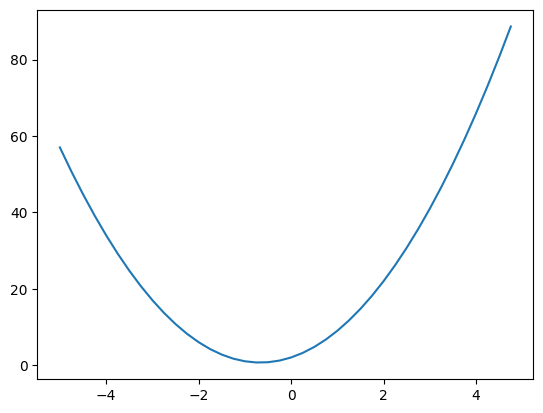

In [6]:
# plot the function
plt.plot(xs,ys)

In [7]:
h = 0.000000000000001 # the small change
x = -5
dydx = (f(x + h) - f(x)) / h
dydx

-28.421709430404004

Partial Derivatives

In [8]:
h = 0.00001
a = 2.0
b = -3.0
c = 10.0
d = a*b + c

#derivative with respect to a
d1 = a * b + c
a += h 
d2 = a * b + c
print("d1", d1)
print("d2", d2)
print("slope with respect to a : ",(d2 - d1)/h)

#derivative with respect to b
d1 = a * b + c
b += h
d2 = a * b + c
print("\nd1", d1)
print("d2", d2)
print("slope with respect to b : ",(d2 - d1)/h)

#derivative with respect to c
d1 = a * b + c
c += h
d2 = a * b + c
print("\nd1", d1)
print("d2", d2)
print("slope with respect to c : ",(d2 - d1)/h)

d1 4.0
d2 3.9999699999999994
slope with respect to a :  -3.000000000064062

d1 3.9999699999999994
d2 3.9999900000999995
slope with respect to b :  2.00001000001393

d1 3.9999900000999995
d2 4.000000000099999
slope with respect to c :  0.9999999999621422


#### Creating the Value Class

In [33]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0 
        self._prev = set(_children) # keeps track of the value objects that led to the new value object
        self._op = _op  # keeps track of the operator that led to the value object
        self.label = label 
        
    def __repr__(self):
        return f"ValueData=({self.data}, label=({self.label}))"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
        
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    

In [34]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b ; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d*f ; L.label = 'L'
L

ValueData=(-8.0, label=(L))

In [35]:
d._prev

{ValueData=(-6.0, label=(e)), ValueData=(10.0, label=(c))}

In [36]:
d._op

'+'

In [37]:
import sys

In [38]:
sys.getrefcount(d)

3

#### Graphviz visualization

In [39]:
from graphviz import Digraph

In [40]:
def trace(root):
    # build the set of all the nodes and edges in a graph
    nodes , edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
            
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir': 'LR'})

    nodes , edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph we create a rectangular node
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if the value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # connect the node to iit
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

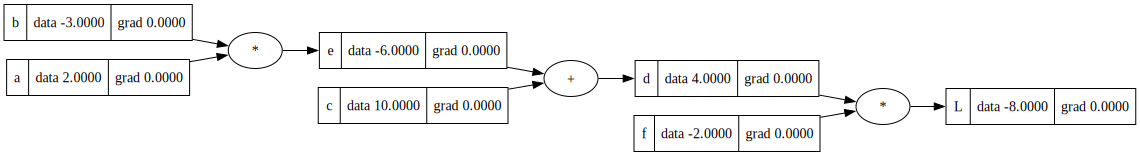

In [41]:
draw_dot(L)

In [ ]:
def lol():
    h = 0.0001
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d*f ; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)